In [39]:
# Task 1 — Data Exploration with Pandas
import pandas as pd

In [40]:
from google.colab import files
uploaded = files.upload()

Saving students.csv to students (1).csv


In [41]:
df = pd.read_csv("students.csv")

In [42]:
# 1 Print the first 5 rows using
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [43]:
# 2 Print the shape (rows × columns) and the data type of each column using .dtypes
print("Shape (rows, columns):", df.shape)
print("\nData types:")
print(df.dtypes)


Shape (rows, columns): (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [44]:
# 3 Print summary statistics (mean, min, max, std) for all numeric columns using .describe().
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

In [45]:
# 4 Print the count of students who passed and who failed. (Hint: use df['passed'].value_counts())
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


In [46]:
# 5 Compute and print the average score per subject (math, science, english, history, pe) separately for passing and failing students.
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average scores for passing students:")
print(pass_avg)

print("\nAverage scores for failing students:")
print(fail_avg)

Average scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [47]:
# 6 Find and print the student with the highest overall average across all 5 subjects.
df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]
print("Top student by overall average:")
print(top_student[['name', 'overall_avg']])

Top student by overall average:
name           Diana
overall_avg     94.0
Name: 3, dtype: object


In [48]:
# Task 2 — Data Visualization with Matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("students.csv")

# Required columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Add average score column
df['avg_score'] = df[subject_cols].mean(axis=1)

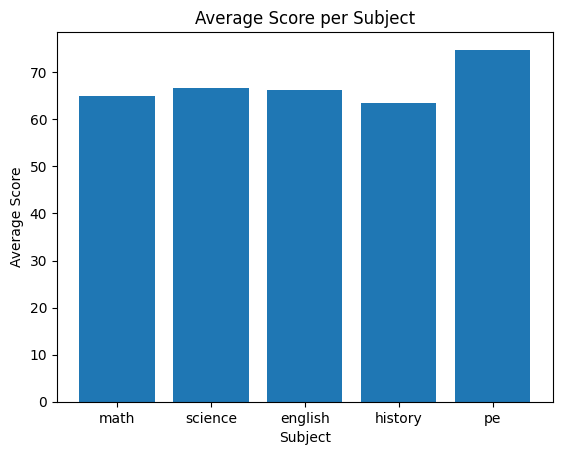

In [49]:
#1 Barchart
subject_avg = df[subject_cols].mean()

plt.figure()
plt.bar(subject_avg.index, subject_avg.values)
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

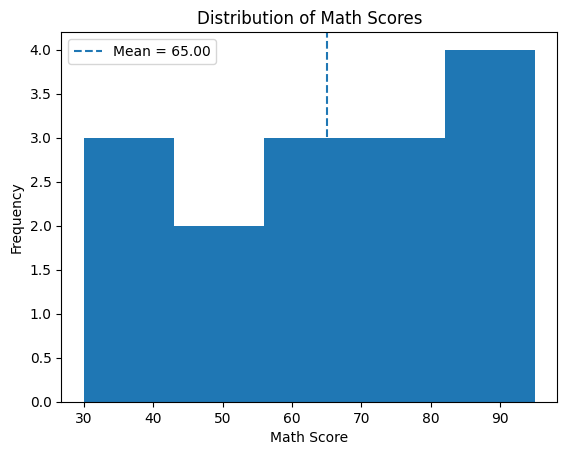

In [50]:
#2 Histogram
plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='--', label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

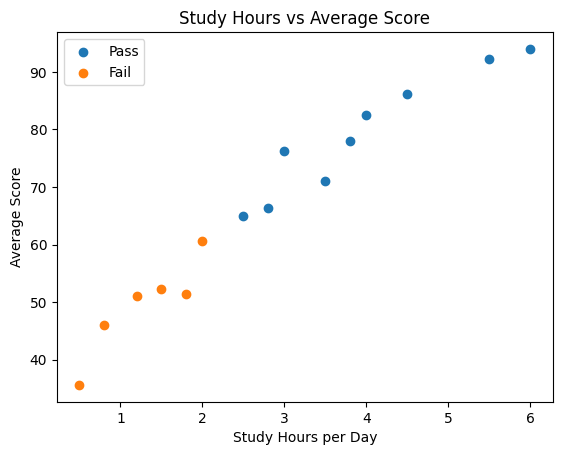

In [51]:
#3 Scatter Plot
plt.figure()

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(
    pass_students['study_hours_per_day'],
    pass_students['avg_score'],
    label="Pass"
)

plt.scatter(
    fail_students['study_hours_per_day'],
    fail_students['avg_score'],
    label="Fail"
)

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_2652/3611365016.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


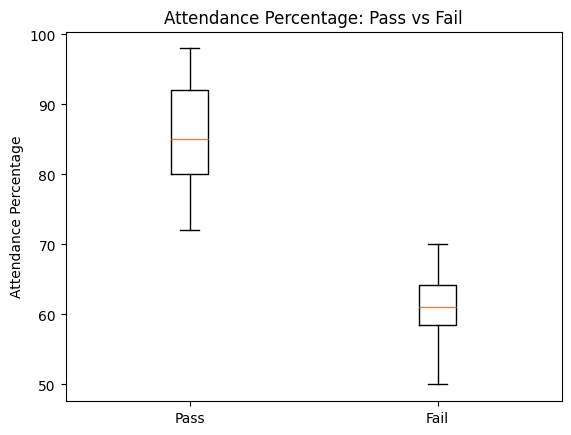

In [52]:
#4 Box Plot
pass_attendance = pass_students['attendance_pct'].tolist()
fail_attendance = fail_students['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_box.png")
plt.show()

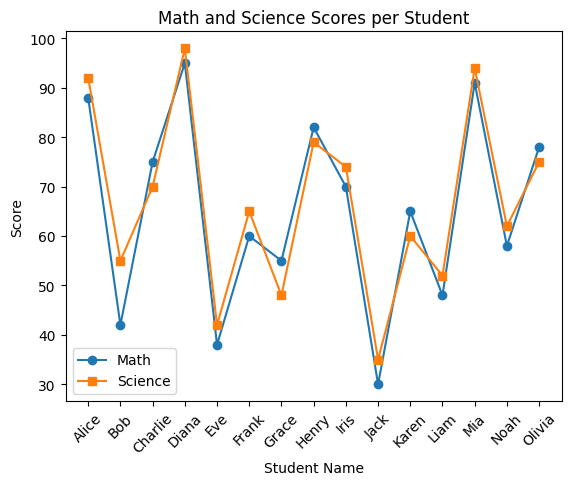

In [53]:
#5 Line Plot
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

In [54]:
# Task 3 — Data Visualization with Seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("students.csv")

# Compute average score
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

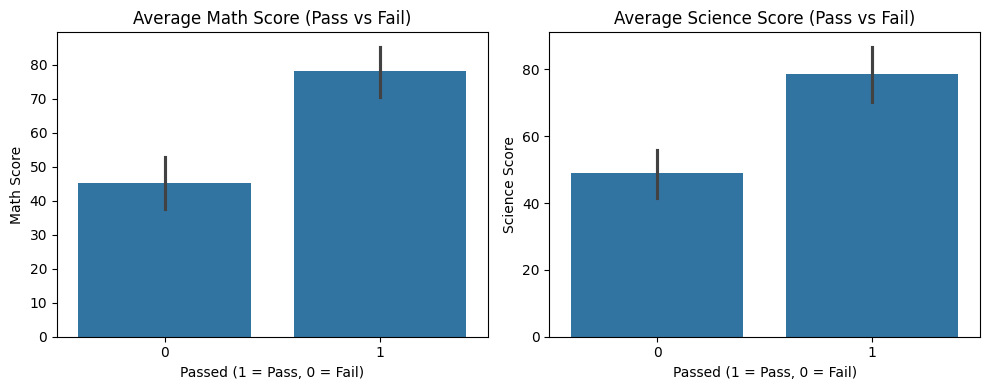

In [55]:
# Seaborn bar plot
plt.figure(figsize=(10, 4))

# Math bar plot
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (1 = Pass, 0 = Fail)")
plt.ylabel("Math Score")

# Science bar plot
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (1 = Pass, 0 = Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("seaborn_bar_scores.png")
plt.show()

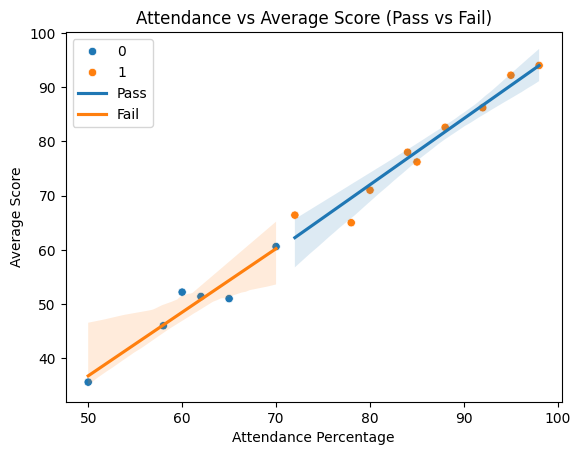

In [56]:
# Seaborn scatter plot
plt.figure()

# Scatter points coloured by pass/fail
sns.scatterplot(
    data=df,
    x='attendance_pct',
    y='avg_score',
    hue='passed'
)

# Regression line for passing students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for failing students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("seaborn_scatter_reg.png")
plt.show()

In [57]:
# Seaborn made these plots easier than Matplotlib because it automatically
# handles aggregation (such as computing means) and applies clean default styling.
# With Matplotlib, more manual work is needed for colors, legends, and aesthetics,
# while Seaborn provides higher-level plotting with less code.

In [58]:
# Task 4 — Machine Learning with scikit-learn
# Step 1 — Prepare Data:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("students.csv")

features = [
    'math', 'science', 'english', 'history',
    'pe', 'attendance_pct', 'study_hours_per_day'
]

X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [59]:
 # Step 2 — Train the Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [60]:
# Step 3 — Evaluate the Model
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(names, y_test, y_pred):
    status = "✅ Correct" if actual == predicted else " Wrong"
    print(f"{name}: Actual={actual}, Predicted={predicted} → {status}")

Test Accuracy: 1.0
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


In [61]:
# Step 4 — Feature Importance
coefficients = model.coef_[0]
feature_importance = sorted(
    zip(features, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

for feature, coef in feature_importance:
    print(f"{feature}: {coef:.3f}")

english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


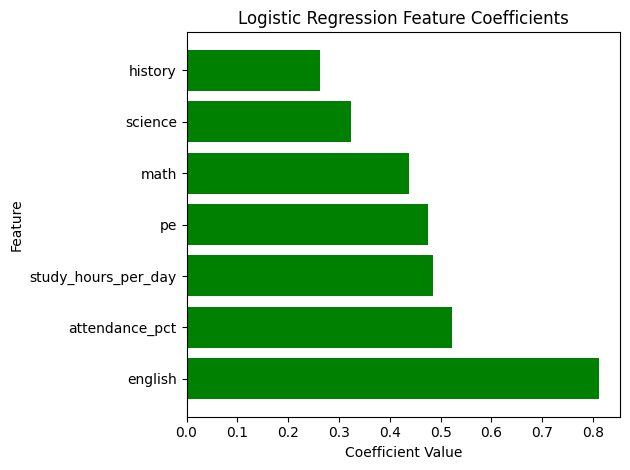

In [62]:
# Step 5 — Predict for a New Student
import matplotlib.pyplot as plt

colors = ['green' if coef > 0 else 'red' for _, coef in feature_importance]

plt.figure()
plt.barh(
    [f for f, _ in feature_importance],
    [c for _, c in feature_importance],
    color=colors
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()